# 1 Neural networks with PyTorch

In this notebook, we will build a classifier for the Wisconsin breast-cancer dataset. We will start with a single linear layer, examine gradients and the training loop, and then add a hidden layer. The dataset contains numerical measurements of cell nuclei; we use it to study the learning workflow.

In [1]:
import random
import numpy as np
import torch

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.set_num_threads(2)

seed_everything(42)

## 1.1 Inspect the data before the model
There are 569 samples and 30 numerical measurements. The original scikit-learn labels use 0 for malignant and 1 for benign. We explicitly reverse them here: **1 = malignant, 0 = benign**. All later scores use this convention.

[Dataset documentation](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_breast_cancer.html)

In [2]:
import numpy as np, pandas as pd, torch
from torch import nn
from sklearn.datasets import load_breast_cancer
data = load_breast_cancer()
display(pd.DataFrame(data.data, columns=data.feature_names).head(3))
labels = (data.target == 0).astype(int)
display(pd.Series(labels).value_counts().rename(index={0: "benign", 1: "malignant"}).to_frame("samples"))

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.8,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.6,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.9,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.8,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.0,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.5,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758


,samples
benign,357
malignant,212


*Assignment: What does success mean?*

If most samples belong to one class, could a model achieve reasonable accuracy while ignoring the other class? Explain why sensitivity to the malignant class and the confusion matrix matter.

*Answer:*

Always predicting the majority class can produce apparently respectable accuracy without identifying any malignant samples. Inspect each class. In this teaching dataset, label 1 explicitly denotes malignant. Which errors matter depends on the intended use; a classroom result is not clinical validation.

## 1.2 Separate training, validation and test data
Think of training as practice questions, validation as feedback for choosing a study method, and test as the final exam. Looking at test scores while repeatedly changing the model turns the exam into more practice data.

The function below makes a stratified **60% / 20% / 20%** split: approximately similar class proportions in each part. It then learns each feature's mean and standard deviation **from training data only** and uses those values to scale every split. This avoids allowing validation/test measurements to influence preprocessing.

In [3]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, TensorDataset

def cancer_splits(seed=42):
    """60/20/20 stratified split; fit preprocessing on training data only.

    Relabel explicitly: 1 = malignant, 0 = benign (opposite sklearn's coding).
    The returned test arrays should be opened only after model selection.
    """
    source = load_breast_cancer()
    x = source.data.astype(np.float32)
    y = (source.target == 0).astype(np.float32)
    idx = np.arange(len(y))
    train, remainder = train_test_split(idx, test_size=0.4, stratify=y, random_state=seed)
    val, test = train_test_split(remainder, test_size=0.5, stratify=y[remainder], random_state=seed)
    scaler = StandardScaler().fit(x[train])
    result = {"scaler": scaler, "feature_names": source.feature_names}
    for name, rows in [("train", train), ("val", val), ("test", test)]:
        result[name] = (scaler.transform(x[rows]).astype(np.float32), y[rows])
        result[name + "_ids"] = rows
    return result

def loader(x, y, batch_size=32, shuffle=False, seed=42):
    return DataLoader(
        TensorDataset(torch.as_tensor(x, dtype=torch.float32), torch.as_tensor(y, dtype=torch.float32)),
        batch_size=batch_size, shuffle=shuffle,
        generator=torch.Generator().manual_seed(seed), num_workers=0,
    )

In [4]:
splits = cancer_splits()
x_train, y_train = splits["train"]
x_val, y_val = splits["val"]
print("Training:", x_train.shape, "Validation:", x_val.shape)
print("Mean of the first standardized training feature:", round(float(x_train[:, 0].mean()), 6))
train_loader = loader(x_train, y_train, shuffle=True)
val_loader = loader(x_val, y_val)
batch_x, batch_y = next(iter(train_loader))
print("A batch:", batch_x.shape, batch_y.shape)

Training: (341, 30) Validation: (114, 30)
Mean of the first standardized training feature: -0.0
A batch: torch.Size([32, 30]) torch.Size([32])


## 1.3 Tensors and gradients
A tensor is an array PyTorch can use for calculation. A **gradient** tells us how a small change to a number would change the loss. PyTorch can calculate these gradients automatically.

For the simple function `loss = w²`, the derivative is `2w`. With `w = 3`, we expect a gradient of 6. This tiny example illustrates differentiation; it is not yet our classification loss.

In [5]:
w = torch.tensor(3.0, requires_grad=True)
toy_loss = w ** 2
toy_loss.backward()
print("Loss:", toy_loss.item(), "Gradient:", w.grad.item())

Loss: 9.0 Gradient: 6.0


*Assignment: Follow one downhill step*

Use `new_w = w - learning_rate * gradient`. Try learning rates 0.1 and 1.1. Does a bigger step always improve the loss?

In [6]:
for learning_rate in [0.1, 1.1]:
    new_w = w.detach() - learning_rate * w.grad
    print(learning_rate, "old loss:", w.item() ** 2, "new loss:", new_w.item() ** 2)

0.1 old loss: 9.0 new loss: 5.760000457763681
1.1 old loss: 9.0 new loss: 12.960002746582177


*Answer:*

At 0.1, w becomes 2.4 and loss becomes 5.76. At 1.1, w becomes -3.6 and loss becomes 12.96. A sufficiently large update overshoots. Gradients are not probabilities or measures of feature importance.

## 1.4 One neuron is a linear score
The model multiplies the 30 measurements by 30 learned weights and adds a bias. The result is a **logit**, an unrestricted real-valued score. A sigmoid converts that score to a number between 0 and 1.

With this architecture and binary cross-entropy training, we have logistic regression. `nn.Linear(30, 1)` means 30 inputs and one output, not 30 layers.

In [7]:
seed_everything(42)
linear_model = nn.Linear(30, 1)
logits = linear_model(batch_x).squeeze(-1)
print("Logits:", logits[:4].detach().numpy())
print("Probabilities:", torch.sigmoid(logits[:4]).detach().numpy())
print("Trainable parameters:", sum(p.numel() for p in linear_model.parameters()))

Logits: [-0.6265909  -0.35816842  0.924991    0.29788744]
Probabilities: [0.34828395 0.41140303 0.716058   0.573926  ]
Trainable parameters: 31


## 1.5 The loss compares scores with known labels
`BCEWithLogitsLoss` combines sigmoid and binary cross-entropy stably. **Pass raw logits to it; do not add a sigmoid to the model.** Use sigmoid later when you need probabilities.

Binary cross-entropy is nonnegative and has **no finite upper bound**. A confidently wrong prediction can have loss much larger than 1. Loss and accuracy measure different things.

In [8]:
loss_fn = nn.BCEWithLogitsLoss()
example_logits = torch.tensor([0.0, -10.0, 10.0])
example_labels = torch.ones(3)  # All three true labels are positive.
individual_losses = nn.BCEWithLogitsLoss(reduction="none")(example_logits, example_labels)
display(pd.DataFrame({"logit": example_logits.numpy(),
                      "probability": torch.sigmoid(example_logits).numpy(),
                      "loss_if_label_is_1": individual_losses.numpy()}))

,logit,probability,loss_if_label_is_1
0,0.0,0.500000,0.693147
1,-10.0,0.000045,10.000046
2,10.0,0.999955,0.000045


## 1.6 Trace one update
You do not need to memorize this code. Point to where the model predicts, where the answer is checked, and where parameters change.

`zero_grad` clears old gradients; `backward` computes new gradients; `step` updates parameters. Here `squeeze(-1)` removes only the final one-element output axis, so a batch of one sample still works.

In [9]:
optimizer = torch.optim.Adam(linear_model.parameters(), lr=0.01)
linear_model.train()
optimizer.zero_grad()
logits = linear_model(batch_x).squeeze(-1)
loss = loss_fn(logits, batch_y)
loss.backward()
optimizer.step()
print("Loss before this update:", round(loss.item(), 4))

Loss before this update: 0.6167


*Assignment: Explain the six steps*

Describe what each of the six training steps in the preceding cell does. Which two operations should not happen during validation?

*Answer:*

Take a batch, predict, compare with labels, compute how parameters affect the loss, then update them. Validation should not call backward or optimizer.step. It should use model.eval() and disabled gradient recording. zero_grad clears accumulated gradients before a new update.

## 1.7 Repeat and look at learning curves
The following function repeats the same update over batches and epochs, evaluates after each epoch, and retains an independent copy of the best validation-loss weights. Its definition is included below.

The validation pass uses `model.eval()` and no gradient recording. Loss averages are weighted by batch size so a short final batch is counted correctly.

In [10]:
from copy import deepcopy
from torch import nn
import pandas as pd
from sklearn.metrics import accuracy_score, balanced_accuracy_score, roc_auc_score
import matplotlib.pyplot as plt

def fit_binary(model, train_loader, val_loader, epochs=30, lr=0.001, weight_decay=0.0):
    """CPU training for small exercises. Return independent best-validation weights.

    Models return ONE LOGIT per example. The loss includes the sigmoid.
    Loss means are weighted by sample count, including the last short batch.
    """
    loss_fn = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    best_loss = float("inf")
    best_weights = deepcopy(model.state_dict())
    history = []
    for epoch in range(epochs):
        values = {}
        for phase, batches in [("train", train_loader), ("val", val_loader)]:
            model.train(phase == "train")
            total_loss, count = 0.0, 0
            with torch.set_grad_enabled(phase == "train"):
                for x, y in batches:
                    if phase == "train":
                        optimizer.zero_grad()
                    logits = model(x).squeeze(-1)
                    loss = loss_fn(logits, y)
                    if phase == "train":
                        loss.backward()
                        optimizer.step()
                    total_loss += loss.item() * len(y)
                    count += len(y)
            values[phase + "_loss"] = total_loss / count
        if values["val_loss"] < best_loss:
            best_loss = values["val_loss"]
            best_weights = deepcopy(model.state_dict())
        history.append({"epoch": epoch + 1, **values})
    model.load_state_dict(best_weights)
    model.eval()
    return pd.DataFrame(history)

@torch.no_grad()
def probabilities(model, x):
    model.eval()
    return torch.sigmoid(model(torch.as_tensor(x, dtype=torch.float32)).squeeze(-1)).numpy()

def binary_scores(y, probability):
    predicted = np.asarray(probability) >= 0.5
    return {
        "accuracy": accuracy_score(y, predicted),
        "balanced_accuracy": balanced_accuracy_score(y, predicted),
        "ROC_AUC": roc_auc_score(y, probability),
    }

def plot_history(history, title="Training and validation loss"):
    ax = history.plot(x="epoch", y=["train_loss", "val_loss"], figsize=(6, 3.5))
    ax.set(xlabel="Epoch (one pass through training data)", ylabel="Binary cross-entropy", title=title)
    plt.tight_layout()
    plt.show()

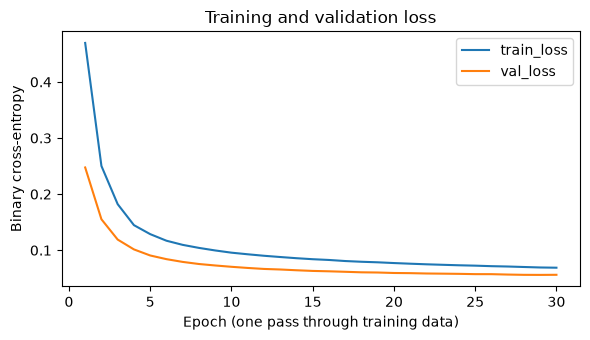

accuracy             0.982456
balanced_accuracy    0.976744
ROC_AUC              0.999672
Name: Validation, dtype: float64

In [11]:
seed_everything(42)
linear_model = nn.Linear(30, 1)  # Start afresh for a reproducible comparison.
history = fit_binary(linear_model, loader(x_train, y_train, shuffle=True), val_loader,
                     epochs=30, lr=0.01)
plot_history(history)
display(pd.Series(binary_scores(y_val, probabilities(linear_model, x_val)), name="Validation"))

**Reading the plot:** each point on the training curve summarizes a pass in which weights changed; the validation curve is measured afterwards with fixed weights. Their difference is useful, but it is not a perfectly controlled comparison.

**ROC-AUC:** how often a randomly chosen positive receives a higher score than a randomly chosen negative; 0.5 corresponds to random ranking and 1 to perfect ranking on these samples. **Balanced accuracy** averages the recall of the two classes. Neither metric proves performance on a new laboratory's data.

*Assignment: Add a hidden layer*

Change the starting linear model to `nn.Sequential(nn.Linear(30, 16), nn.ReLU(), nn.Linear(16, 1))`. A ReLU keeps positive values and sets negative values to zero. Does the more flexible model improve validation performance?

In [12]:
seed_everything(42)
candidate = nn.Sequential(nn.Linear(30, 16), nn.ReLU(), nn.Linear(16, 1))
candidate_history = fit_binary(candidate, loader(x_train, y_train, shuffle=True), val_loader,
                               epochs=30, lr=0.01)
display(pd.Series(binary_scores(y_val, probabilities(candidate, x_val)), name="Candidate validation"))

accuracy             0.991228
balanced_accuracy    0.988372
ROC_AUC              0.999672
Name: Candidate validation, dtype: float64

*Answer:*

There is no promised winner. This dataset may already be well handled by a linear boundary. The hidden layer has 16 learned features; the output remains one raw logit. A small validation-set difference may be sampling variation.

*Optional assignment: Why an activation?*

What happens if two linear layers have no activation between them? Write the algebra, or compare their predictions conceptually.

*Answer:*

Composing Wx+b with Vz+c gives VWx+Vb+c, another affine map. Extra linear layers alone do not introduce nonlinear decision boundaries. The ReLU makes the hidden-layer model more expressive.